# Explore here

📝 Instrucciones
Sistema de predicción de ventas
Queremos establecer el almacén de nuestra empresa en otra localización y necesitamos estimar el ritmo de las ventas, que desde la creación de la empresa ha ido en aumento, para los próximos meses, a fin de proveer el espacio que necesitaremos.

Paso 1: Carga del conjunto de datos

In [31]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

from statsmodels.tsa.arima.model import ARIMA
from pmdarima import auto_arima

import warnings
url="https://breathecode.herokuapp.com/asset/internal-link?id=2546&path=sales.csv"

df=pd.read_csv(url)

df.info()


<class 'pandas.DataFrame'>
RangeIndex: 366 entries, 0 to 365
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   date    366 non-null    str    
 1   sales   366 non-null    float64
dtypes: float64(1), str(1)
memory usage: 5.8 KB


convertir fecha  en formato fecha

In [32]:
df["date"] = pd.to_datetime(df["date"])
df = df.set_index("date")

df.head()

,sales
date,
2022-09-03 17:10:08.079328,55.292157
2022-09-04 17:10:08.079328,53.803211
2022-09-05 17:10:08.079328,58.141693
2022-09-06 17:10:08.079328,64.530899
2022-09-07 17:10:08.079328,66.013633


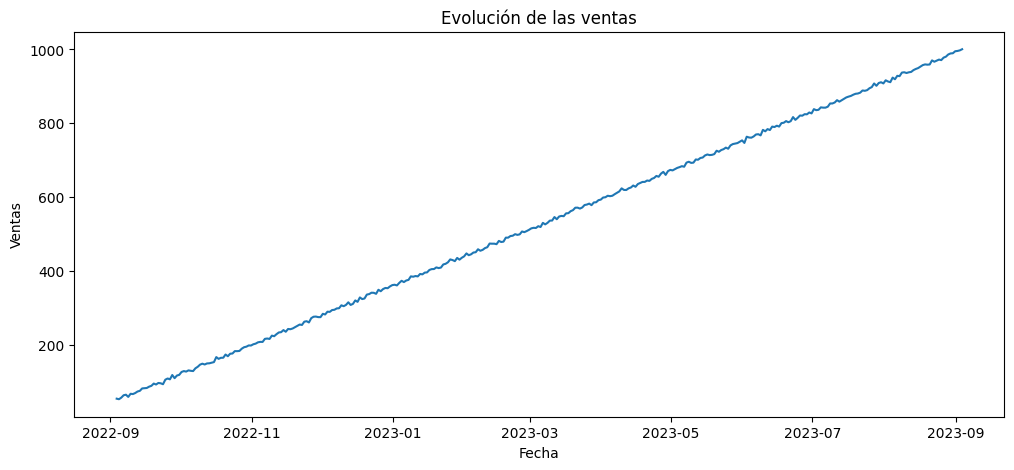

In [33]:
plt.figure(figsize=(12, 5))
plt.plot(df.index, df)
plt.title("Evolución de las ventas")
plt.xlabel("Fecha")
plt.ylabel("Ventas")
plt.show()

Conclusiones:
La serie temporal tiene una frecuencia diaria, además se visualiza una tendencia ascendente.


Paso 2: Construye y analiza la serie temporal

Descomposición de una sserie temporal, se utiliza period=30 para ver patrones cada 30 días 

In [34]:
decomposition = seasonal_decompose(df["sales"], period=30)
decomposition

Análisis de tendencia

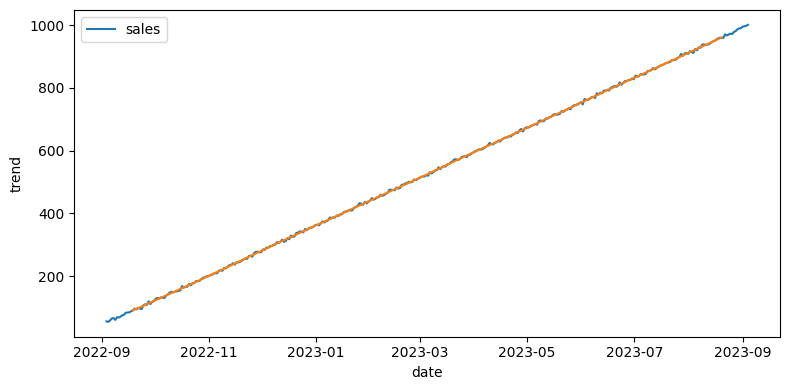

In [35]:
trend = decomposition.trend

fig, axis = plt.subplots(figsize = (8, 4))

sns.lineplot(data = df)
sns.lineplot(data = trend)

plt.tight_layout()

plt.show()

Conclusiones:

La línea naranja representa la tendencia de la serie temporal de ventas.
Se visualiza que la tendencia coincide con los datos originales de ventas, esto quiere decir que hay un crecimiento constante en ventas a lo largo del tiempo y hay poco ruido en los datos.

Análisis de estacionalidad

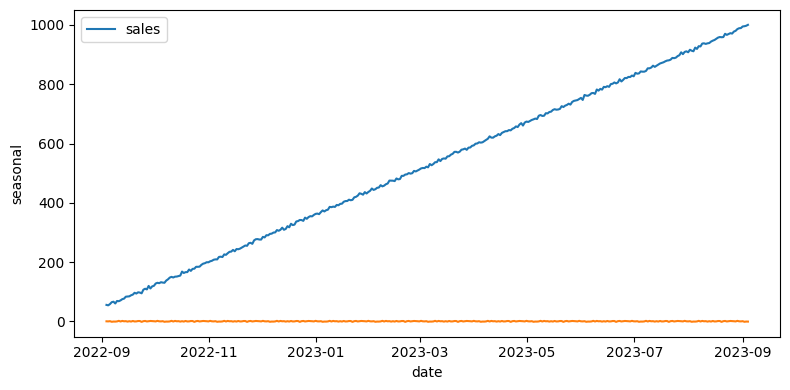

ERROR:tornado.general:Uncaught exception in ZMQStream callback
Traceback (most recent call last):
  File "/home/vscode/.local/lib/python3.11/site-packages/zmq/eventloop/zmqstream.py", line 565, in _log_error
    f.result()
  File "/home/vscode/.local/lib/python3.11/site-packages/ipykernel/kernelbase.py", line 584, in shell_channel_thread_main
    _, msg2 = self.session.feed_identities(msg, copy=False)
              ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/home/vscode/.local/lib/python3.11/site-packages/jupyter_client/session.py", line 998, in feed_identities
    raise ValueError(msg)
ValueError: DELIM not in msg_list
ERROR:tornado.general:Uncaught exception in ZMQStream callback
Traceback (most recent call last):
  File "/home/vscode/.local/lib/python3.11/site-packages/zmq/eventloop/zmqstream.py", line 565, in _log_error
    f.result()
  File "/home/vscode/.local/lib/python3.11/site-packages/ipykernel/kernelbase.py", line 584, in shell_channel_thread_main
    _, msg2 = se

In [ ]:
seasonal = decomposition.seasonal

fig, axis = plt.subplots(figsize = (8, 4))

sns.lineplot(data = df) # Representa las ventas
sns.lineplot(data = seasonal)

plt.tight_layout()

plt.show()

Conclusiones:

La estaacionalidad es muy baja por lo que se puede decir que no hay un patrón repetitivo en ventas.
En esta serie temporal predomina la tendencia ascendente.